In [1]:
!pip install adjustText

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
from adjustText import adjust_text
import random

In [3]:
# Specifying samples (1: control, 0: LPHN2KD)
genotype = 1

# Specifying the columns you want to load
if genotype:
    columns_to_load = ['symbol', 'mR3_scr_flow_2-mR3_scr_static_2_log2FC', 'mR3_scr_flow_2-mR3_scr_static_2_adjPval']
    df = pd.read_csv('deg_values_DESeq2.csv', usecols=columns_to_load).dropna()
    df=df.rename(columns = {'mR3_scr_flow_2-mR3_scr_static_2_log2FC':'avg_log2FC','mR3_scr_flow_2-mR3_scr_static_2_adjPval':'p_val_adj'})
    samplename = 'scrambled'
else:
    columns_to_load = ['symbol', 'mR3_L2KD_flow_2-mR3_L2KD_static_2_log2FC', 'mR3_L2KD_flow_2-mR3_L2KD_static_2_adjPval']
    df = pd.read_csv('deg_values_DESeq2_LPHN2KD_flow.csv', usecols=columns_to_load).dropna()
    df=df.rename(columns = {'mR3_L2KD_flow_2-mR3_L2KD_static_2_log2FC':'avg_log2FC','mR3_L2KD_flow_2-mR3_L2KD_static_2_adjPval':'p_val_adj'})
    samplename = 'LPHN2KD'

df['nlog10'] = -np.log10(df.p_val_adj)

# First, strip spaces from the 'symbol' column
df['symbol'] = df['symbol'].str.strip()

df.head(50)

,symbol,avg_log2FC,p_val_adj,nlog10
0,FN1,0.133604,6.737164e-01,0.171523
1,SERPINE1,0.259031,4.109320e-01,0.386230
2,THBS1,-0.626826,6.902587e-04,3.160988
3,HSPG2,-0.639778,1.233670e-02,1.908801
4,HMOX1,4.418873,1.392252e-23,22.856282
5,CCN2,-0.707729,8.713455e-03,2.059810
6,SLC38A2,1.539539,1.370377e-14,13.863160
7,PODXL,2.269824,2.136495e-14,13.670298
8,PTGS2,3.103213,7.108753e-13,12.148207
9,MMP1,0.553468,4.414682e-03,2.355101


In [4]:
# Select the genes upregulated and downregulated
upregulated = df[(df['avg_log2FC'] > 1) & (df['nlog10'] > 2)]['symbol'].tolist()
downregulated = df[(df['avg_log2FC'] < -1) & (df['nlog10'] > 2)]['symbol'].tolist()

In [5]:
def map_color(a):
    symbol, avg_log2FC, nlog10 = a
    
    if abs(avg_log2FC) < 1 or nlog10 < 2:
        return 'non_significant'
    if symbol in upregulated:
        return 'Flow-upregulated'
    if symbol in downregulated:
        return 'Flow-downregulated'

df['Genes'] = df[['symbol', 'avg_log2FC', 'nlog10']].apply(map_color, axis = 1)

In [6]:
df.head(30)

,symbol,avg_log2FC,p_val_adj,nlog10,Genes
0,FN1,0.133604,6.737164e-01,0.171523,non_significant
1,SERPINE1,0.259031,4.109320e-01,0.386230,non_significant
2,THBS1,-0.626826,6.902587e-04,3.160988,non_significant
3,HSPG2,-0.639778,1.233670e-02,1.908801,non_significant
4,HMOX1,4.418873,1.392252e-23,22.856282,Flow-upregulated
5,CCN2,-0.707729,8.713455e-03,2.059810,non_significant
6,SLC38A2,1.539539,1.370377e-14,13.863160,Flow-upregulated
7,PODXL,2.269824,2.136495e-14,13.670298,Flow-upregulated
8,PTGS2,3.103213,7.108753e-13,12.148207,Flow-upregulated
9,MMP1,0.553468,4.414682e-03,2.355101,non_significant


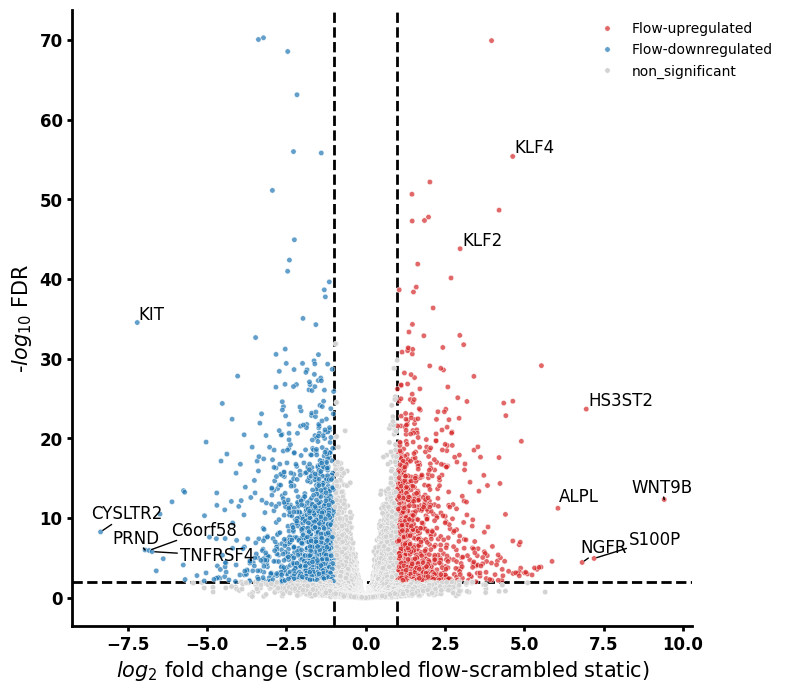

In [7]:
plt.figure(figsize = (8,8))

# Define your hues and desired alpha values
hues = [
    'Flow-upregulated', 
    'Flow-downregulated',
    'non_significant'
]

sizes = {
    'Flow-upregulated': 15, 
    'Flow-downregulated': 15,
    'non_significant':15
}

colors = [(0.839, 0.153, 0.157, 1), (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1), 'lightgrey']
alphas = [0.7, 0.7, 1]  # Set alpha values

# Create RGBA palette
palette = {hue: to_rgba(color, alpha) for hue, color, alpha in zip(hues, colors, alphas)}

ax = sns.scatterplot(data = df, x = 'avg_log2FC', y = 'nlog10',
                    hue = 'Genes', hue_order = hues,
                    palette = palette,
                    size='Genes', sizes=sizes)

ax.axhline(2, zorder = 0, c = 'k', lw = 2, ls = '--')
ax.axvline(1, zorder = 0, c = 'k', lw = 2, ls = '--')
ax.axvline(-1, zorder = 0, c = 'k', lw = 2, ls = '--')


# Top-right corner: High avg_log2FC and high nlog10 in LPHN2-target genes
top_right = df[(df['Genes']=='Flow-upregulated')].nlargest(5, ['avg_log2FC', 'nlog10'])

# Top-left corner: Low avg_log2FC (but positive) and high nlog10
# Top-left corner: Largest negative avg_log2FC by absolute value and high nlog10
df['abs_avg_log2FC'] = df['avg_log2FC'].abs()
top_left = df[(df['Genes']=='Flow-downregulated')].nlargest(5, ['abs_avg_log2FC', 'nlog10'])
selected = df[df['symbol'].isin(['KLF2', 'KLF4'])]

# Combine the dataframes
to_label = pd.concat([top_right, top_left, selected])

# Remove duplicated rows based on the 'symbol' column
to_label = to_label.drop_duplicates(subset='symbol')

# Create an empty list to store text objects
texts = []

# Iterate over the DataFrame to_label and add text annotations
for _, row in to_label.iterrows():
    texts.append(ax.text(row['avg_log2FC'], row['nlog10'], row['symbol'], fontsize=12))

adjust_text(texts,force_text=(0.1,0.1),arrowprops=dict(arrowstyle="-",lw=1))

# Change the size legend title
handles, labels = ax.get_legend_handles_labels()
# Add custom spacing before 4th and 10th label using '\n' in the front of each label
formatted_labels = [
    ('\n' + label) if index in [8] else label
    for index, label in enumerate(labels)
]
plt.legend(handles, formatted_labels, loc=1, bbox_to_anchor = (1.15,1), frameon = False)

for axis in ['bottom', 'left']:
    ax.spines[axis].set_linewidth(2)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(width = 2)

plt.xticks(size = 12, weight = 'bold')
plt.yticks(size = 12, weight = 'bold')

plt.xlabel(f"$log_{2}$ fold change ({samplename} flow-{samplename} static)", size = 15)
plt.ylabel("-$log_{10}$ FDR", size = 15)

plt.savefig(f'volcano_{samplename}_flow_with_top10_label.png', dpi = 600, bbox_inches = 'tight', facecolor = 'white')

plt.show()